# Formula 1 Race Intelligence

## Exploratory Data Analysis (EDA) - Telemetry

### Objetivo

Este notebook tiene como objetivo realizar el análisis exploratorio de los datasets `car_data_fast_lap_raw.csv` y `location_fast_lap_raw.csv`, que contienen información de telemetría correspondiente a las vueltas más rápidas registradas para cada piloto y sesión.

Estos datasets representan la parte más detallada del proyecto, ya que permiten analizar el comportamiento del monoplaza a lo largo de una vuelta mediante variables como:

- Velocidad.
- Revoluciones por minuto (RPM).
- Marcha engranada.
- Uso del acelerador.
- Uso del freno.
- Activación del DRS.
- Posición en pista.
- Circuito.
- Piloto.
- Temporada.

El análisis permitirá identificar valores nulos, duplicados, posibles anomalías y patrones relevantes en la telemetría de los monoplazas.

Además, servirá como base para futuras visualizaciones avanzadas dentro del dashboard de Race Intelligence, donde se podrán comparar pilotos, analizar trazadas y estudiar el rendimiento durante las vueltas rápidas.

## Importación de librerías

Se importan la librería necesarias para la manipulación, análisis y visualización de los datos.

In [8]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Carga de los datasets

A continuación se carga el dataset de telemetría.

In [9]:
car_data = pd.read_csv("../data/raw/car_data_fast_lap_raw.csv")

location_data = pd.read_csv("../data/raw/location_fast_lap_raw.csv")

print("Datasets cargados correctamente")

Datasets cargados correctamente


In [10]:
print("=" * 60)
print("DATASET: CAR DATA")
print("=" * 60)

display(car_data.head())

print()

print("=" * 60)
print("DATASET: LOCATION DATA")
print("=" * 60)

display(location_data.head())

DATASET: CAR DATA


,date,session_key,throttle,brake,rpm,speed,meeting_key,driver_number,n_gear,drs,season,country_name,location_name,session_name,session_type,lap_number,lap_duration,lap_start
0,2024-03-01 16:59:10.049000+00:00,9468,100,0,10757,301,1229,1,8,12.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
1,2024-03-01 16:59:10.330000+00:00,9468,100,0,10858,302,1229,1,8,12.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
2,2024-03-01 16:59:10.610000+00:00,9468,100,0,10987,307,1229,1,8,12.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
3,2024-03-01 16:59:10.969000+00:00,9468,100,0,11049,310,1229,1,8,12.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
4,2024-03-01 16:59:11.209000+00:00,9468,100,0,11077,311,1229,1,8,12.0,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00



DATASET: LOCATION DATA


,date,session_key,x,z,meeting_key,driver_number,y,season,country_name,location_name,session_name,session_type,lap_number,lap_duration,lap_start
0,2024-03-01 16:59:10.015000+00:00,9468,-368,-158,1229,1,1535,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
1,2024-03-01 16:59:10.255000+00:00,9468,-359,-158,1229,1,1736,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
2,2024-03-01 16:59:10.495000+00:00,9468,-350,-159,1229,1,1939,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
3,2024-03-01 16:59:10.615000+00:00,9468,-346,-159,1229,1,2041,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00
4,2024-03-01 16:59:10.875000+00:00,9468,-337,-159,1229,1,2264,2024,Bahrain,Sakhir,Qualifying,Qualifying,16,89.179,2024-03-01T16:59:09.939000+00:00


## Inspección inicial Car

En esta sección se revisa la estructura general del dataset: número de filas, columnas, tipos de datos, valores nulos y duplicados.

In [11]:
car_data.shape

(679438, 18)

In [12]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679438 entries, 0 to 679437
Data columns (total 18 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           679438 non-null  object 
 1   session_key    679438 non-null  int64  
 2   throttle       679438 non-null  int64  
 3   brake          679438 non-null  int64  
 4   rpm            679438 non-null  int64  
 5   speed          679438 non-null  int64  
 6   meeting_key    679438 non-null  int64  
 7   driver_number  679438 non-null  int64  
 8   n_gear         679438 non-null  int64  
 9   drs            598457 non-null  float64
 10  season         679438 non-null  int64  
 11  country_name   679438 non-null  object 
 12  location_name  679438 non-null  object 
 13  session_name   679438 non-null  object 
 14  session_type   679438 non-null  object 
 15  lap_number     679438 non-null  int64  
 16  lap_duration   679438 non-null  float64
 17  lap_start      679438 non-nul

In [13]:
car_data.isnull().sum()

date                 0
session_key          0
throttle             0
brake                0
rpm                  0
speed                0
meeting_key          0
driver_number        0
n_gear               0
drs              80981
season               0
country_name         0
location_name        0
session_name         0
session_type         0
lap_number           0
lap_duration         0
lap_start            0
dtype: int64

In [14]:
car_data.duplicated().sum()

np.int64(0)

In [15]:
car_data.describe()

,session_key,throttle,brake,rpm,speed,meeting_key,driver_number,n_gear,drs,season,lap_number,lap_duration
count,679438.000000,679438.000000,679438.000000,679438.000000,679438.000000,679438.000000,679438.000000,679438.000000,598457.000000,679438.000000,679438.000000,679438.000000
mean,9924.230223,68.655202,18.521943,10343.759590,214.500812,1256.207723,29.227147,5.436319,4.589850,2024.666467,29.522324,86.979323
std,524.521947,41.381520,38.861191,1424.885359,73.974198,16.556053,24.228286,1.936791,4.596972,0.678724,19.653186,11.249547
min,9468.000000,0.000000,0.000000,0.000000,0.000000,1229.000000,1.000000,0.000000,0.000000,2024.000000,1.000000,63.971000
25%,9582.000000,27.000000,0.000000,9851.000000,153.000000,1242.000000,11.000000,4.000000,0.000000,2024.000000,12.000000,77.776000
50%,9850.000000,99.000000,0.000000,10807.000000,224.000000,1256.000000,22.000000,6.000000,8.000000,2025.000000,22.000000,87.710000
75%,9975.000000,100.000000,0.000000,11294.000000,278.000000,1270.000000,44.000000,7.000000,8.000000,2025.000000,48.000000,94.087000
max,11299.000000,104.000000,104.000000,13437.000000,356.000000,1286.000000,87.000000,8.000000,14.000000,2026.000000,78.000000,166.056000


## Inspección inicial Location

En esta sección se revisa la estructura general del dataset: número de filas, columnas, tipos de datos, valores nulos y duplicados.

In [16]:
location_data.shape

(688402, 15)

In [17]:
location_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 688402 entries, 0 to 688401
Data columns (total 15 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   date           688402 non-null  object 
 1   session_key    688402 non-null  int64  
 2   x              688402 non-null  int64  
 3   z              688402 non-null  int64  
 4   meeting_key    688402 non-null  int64  
 5   driver_number  688402 non-null  int64  
 6   y              688402 non-null  int64  
 7   season         688402 non-null  int64  
 8   country_name   688402 non-null  object 
 9   location_name  688402 non-null  object 
 10  session_name   688402 non-null  object 
 11  session_type   688402 non-null  object 
 12  lap_number     688402 non-null  int64  
 13  lap_duration   688402 non-null  float64
 14  lap_start      688402 non-null  object 
dtypes: float64(1), int64(8), object(6)
memory usage: 78.8+ MB


In [18]:
location_data.isnull().sum()

date             0
session_key      0
x                0
z                0
meeting_key      0
driver_number    0
y                0
season           0
country_name     0
location_name    0
session_name     0
session_type     0
lap_number       0
lap_duration     0
lap_start        0
dtype: int64

In [19]:
location_data.duplicated().sum()

np.int64(0)

In [20]:
location_data.describe()

,session_key,x,z,meeting_key,driver_number,y,season,lap_number,lap_duration
count,688402.000000,688402.000000,688402.000000,688402.000000,688402.000000,688402.000000,688402.000000,688402.000000,688402.000000
mean,9911.697895,-297.917741,2189.248407,1255.952878,29.199809,1076.979718,2024.654760,29.284129,87.079683
std,509.848799,5261.117611,4333.072052,16.376741,24.208896,6030.643433,0.669371,19.441451,11.254665
min,9468.000000,-16909.000000,-247.000000,1229.000000,1.000000,-15771.000000,2024.000000,1.000000,63.971000
25%,9582.000000,-3475.000000,140.000000,1242.000000,11.000000,-2529.000000,2024.000000,12.000000,77.998000
50%,9846.000000,-183.000000,541.000000,1256.000000,22.000000,443.000000,2025.000000,22.000000,87.807000
75%,9971.000000,2996.000000,2020.000000,1270.000000,44.000000,4142.000000,2025.000000,47.000000,94.152000
max,11295.000000,15582.000000,22291.000000,1286.000000,87.000000,21798.000000,2026.000000,78.000000,166.056000


## Distribución de velocidad

La velocidad es una de las variables más importante dentro de la telemetría de Fórmula 1, ya que permite analizar el comportamiento general de los monoplazas durante las vueltas rápidas registradas.
En esta sección se estudia la distribución de las velocidades registradas para identificar valores habituales, dispersión y posibles registros atípicos.

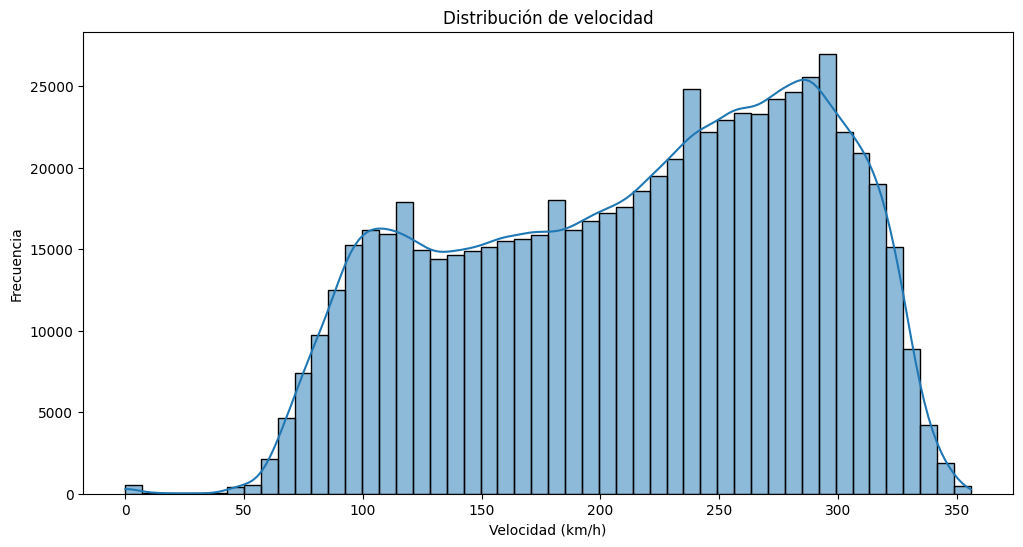

In [22]:
plt.figure(figsize=(12,6))

sns.histplot(
    car_data["speed"],
    bins=50,
    kde=True
)

plt.title("Distribución de velocidad")
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Frecuencia")

plt.show()

La distribución muestra una elevada concentración de frecuencia entre velocidades medias y altas.
Los picos principales corresponden a las zonas donde los monoplazas pasan la mayor parte del tiempo durante una vuelta rápida, mientras que la cola derecha representa las velocidades máximas alcanzadas en recta.

In [24]:
car_data["speed"].describe()

count    679438.000000
mean        214.500812
std          73.974198
min           0.000000
25%         153.000000
50%         224.000000
75%         278.000000
max         356.000000
Name: speed, dtype: float64

### Interpretación

Las estadísticas descriptivas muestran la presencia de valores máximos muy  correctos para un monoplaza de Fórmula 1, que no indican la existencia de registros anómalos que afecten negativamente a determinadas visualizaciones y métricas descriptivas.

## Distribución de RPM

Las revoluciones por minuto permiten estudiar el régimen de funcionamiento del motor durante la vuelta.

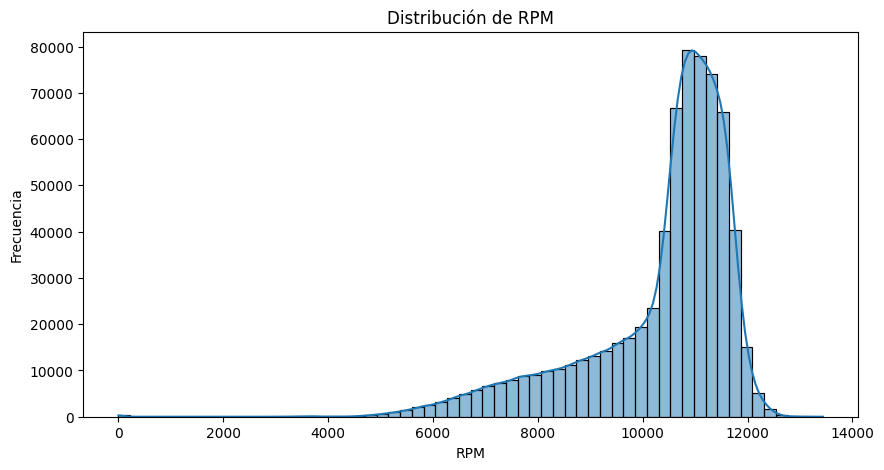

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(
    car_data["rpm"],
    bins=60,
    kde=True
)

plt.title("Distribución de RPM")
plt.xlabel("RPM")
plt.ylabel("Frecuencia")

plt.show()

In [28]:
car_data["rpm"].describe()

count    679438.000000
mean      10343.759590
std        1424.885359
min           0.000000
25%        9851.000000
50%       10807.000000
75%       11294.000000
max       13437.000000
Name: rpm, dtype: float64

### Interpretación

La mayor parte de las observaciones se concentran en regímenes elevados de funcionamiento, reflejando el uso intensivo del motor durante una vuelta rápida. La distribución permite identificar los rangos de RPM más utilizados por los pilotos en condiciones de máximo rendimiento.
Además, para contextualizar estos valores, los monoplazas de Fórmula 1 actuales utilizan unidades de potencia híbridas, limitadas reglamentariamente a un régimen máximo de 15.000 RPM, y en condiciones normales de competición, el motor suele operar por encima de las 4.000 RPM, incluso en situaciones de baja velocidad.
En generaciones anteriores de Fórmula 1, especialmente durante la era de los motores V10 y V8, se alcanzaban regímenes significativamente más elevados, llegando a superar las 19.000 RPM. Por tanto, los valores observados en el dataset, con máximos cercanos a las 12.000 - 13.000 RPM, resultan coherentes con los monoplazas analizados durante las temporadas incluidas en este estudio.

## Distribución de marchas

La variable n_gear permite estudiar qué marchas se utilizan con mayor frecuencia durante una vuelta rápida.

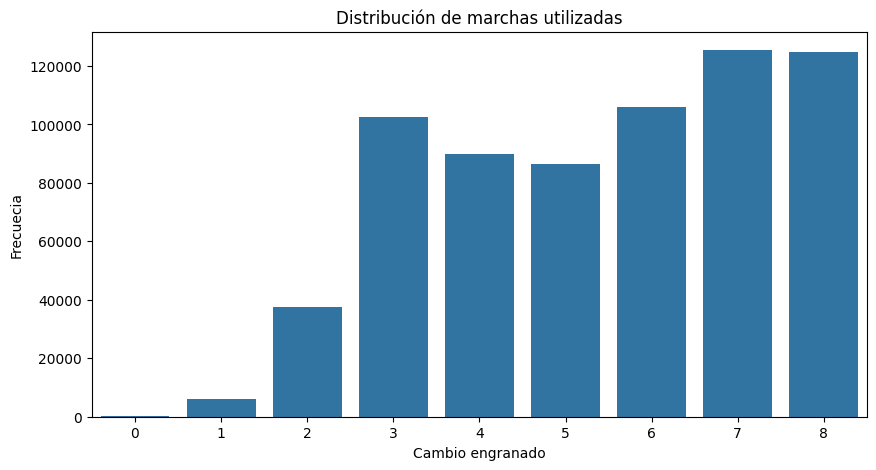

In [32]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=car_data,
    x="n_gear"
)

plt.title("Distribución de marchas utilizadas")
plt.xlabel("Cambio engranado")
plt.ylabel("Frecuecia")


plt.show()

### Interprestación

Las marchas más largas suelen concentrar una mayor cantidad de registros debido al tiempo que los monoplazas permanecen acelerando o circulando a alta velocidad.
Las marchas cortas aparecen asociadas principalmente a curvas lentas y zonas de fuerte frenada.

## Uso del acelerador y del freno

El análisis conjunto de throttle y brake permite estudiar los momentos de aceleración y frenado durante las vueltas rápidas.

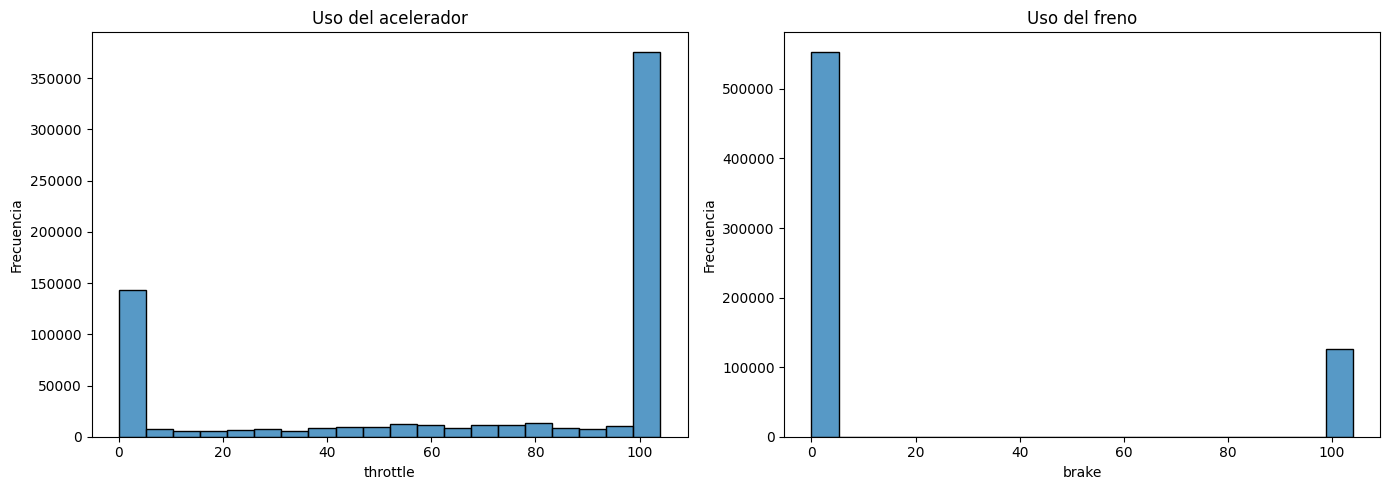

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(
    car_data["throttle"],
    bins=20,
    ax=axes[0]
)

axes[0].set_title("Uso del acelerador")
axes[0].set_ylabel("Frecuencia")

sns.histplot(
    car_data["brake"],
    bins=20,
    ax=axes[1]
)

axes[1].set_title("Uso del freno")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

### Interpretación

Las variables throttle y brake representan las acciones realizadas por el piloto sobre los pedales de acelerador y freno durante la vuelta rápida.

La variable throttle, en sí, indica el porcentaje de apertura del acelerador, tomando valores entre 0 y 100. El 0 para esta caso, significa que el piloto no está acelerando, mientras que un valor de 100 indica que está aplicando toda la potencia disponible del motor.
Se observa una elevada concentración de registros en torno al valor 100, lo que indica que los pilotos pasan una gran parte de la vuelta acelerando al máximo.
También se aprecia una acumulación de registros cercanos a 0, correspondientes principalmente a las zonas de frenada y entrada en curva, donde el piloto debe levantar el pie del acelerador para controlar el monoplaza.

La variable brake se comporta de forma diferente. Según la documentación de OpenF1, esta variable funciona como un indicador binario, tomando únicamente los valores 0 y 100, donde 0 significa que el freno no está siendo pisado, mientras que un valor de 100 representa una frenada activa.

En conjunto, ambas distribuciones reflejan con precisión el estilo de conducción de un monoplaza de Fórmula 1, caracterizado por largos periodos de aceleración máxima combinados con frenadas intensas pero relativamente breves.


## Activación del DRS

El sistema DRS permite reducir la resistencia aerodinámica y aumentar la velocidad punta en determinadas zonas del circuito.

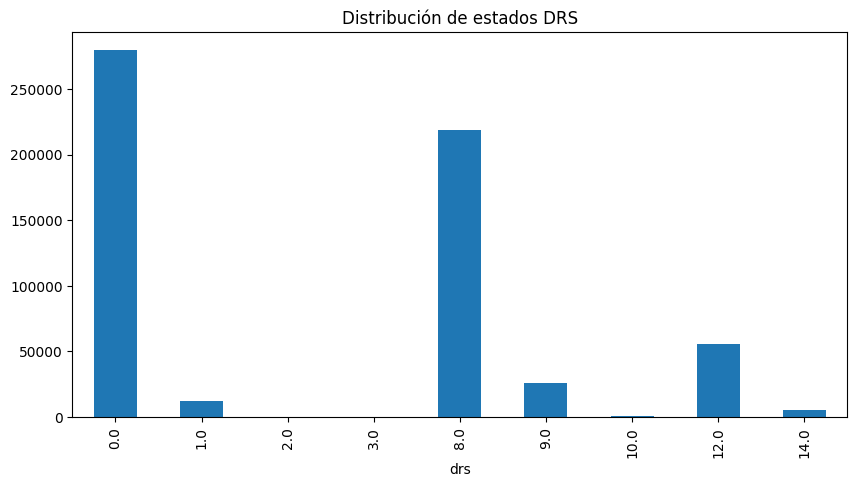

In [35]:
plt.figure(figsize=(10,5))

car_data["drs"].value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Distribución de estados DRS")

plt.show()

### Interpretación

La variable DRS representa el estado del sistema de reducción de resistencia aerodinámica, una tecnología que permite aumentar la velocidad punta del monoplaza mediante la apertura del alerón trasero en determinadas zonas del circuito.
A diferencia de otras variables analizadas anteriormente, el DRS no funciona como una variable binaria simple, sino que OpenF1 registra diferentes códigos numéricos que representan distintos estados del sistema.
Se aprecia que los estados más frecuentes son los valores 0 y 8, seguidos por los estados 12 y 9. Esto indica que durante gran parte de la vuelta los vehículos alternan entre situaciones en las que el DRS permanece inactivo y otras en las que el sistema se encuentra disponible o activado según las condiciones de carrera y la posición del monoplaza en el circuito.
En conjunto, la distribución observada resulta coherente con el funcionamiento del DRS en Fórmula 1, ya que únicamente puede utilizarse en zonas concretas del circuito y bajo determinadas condiciones reglamentarias. Por este motivo, los estados asociados a la activación del sistema aparecen con menor frecuencia que aquellos en los que el DRS permanece cerrado o inactivo.


## Correlación entre variables

La matriz de correlación permite estudiar la relación existente entre las principales variables de rendimiento del monoplaza.

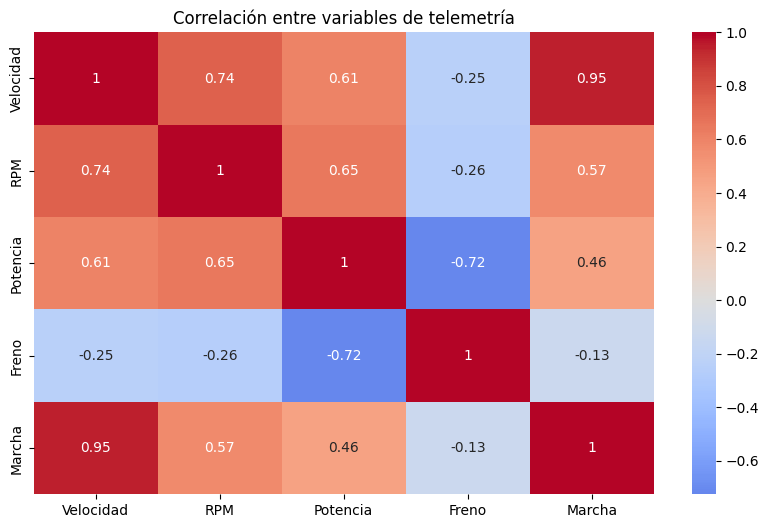

In [40]:
telemetry_cols = {
    "speed": "Velocidad",
    "rpm": "RPM",
    "throttle": "Potencia",
    "brake": "Freno",
    "n_gear": "Marcha"
}

corr = (
    car_data[list(telemetry_cols.keys())]
    .rename(columns=telemetry_cols)
    .corr()
)

plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Correlación entre variables de telemetría")

plt.show()

### Interpretación

La matriz de correlación muestra relaciones coherentes entre las principales variables de telemetría. La correlación más elevada se observa entre Velocidad y Marcha, indicando que a medida que aumenta la velocidad los pilotos utilizan marchas más largas. También se observan correlaciones positivas entre Velocidad, rpm y Potencia, lo que refleja que los mayores niveles de rendimiento se alcanzan cuando el motor trabaja a altas revoluciones y el acelerador se encuentra ampliamente abierto.
Por el contrario, la variable Freno presenta correlaciones negativas con el resto de variables, especialmente con Ptencia, ya que las frenadas suelen coincidir con una reducción del uso del acelerador.
En general, los resultados obtenidos son coherentes con el comportamiento esperado de un monoplaza de Fórmula 1 durante una vuelta rápida.


## Trazada GPS

El dataset de localización permite reconstruir el recorrido realizado por los monoplazas sobre el circuito.

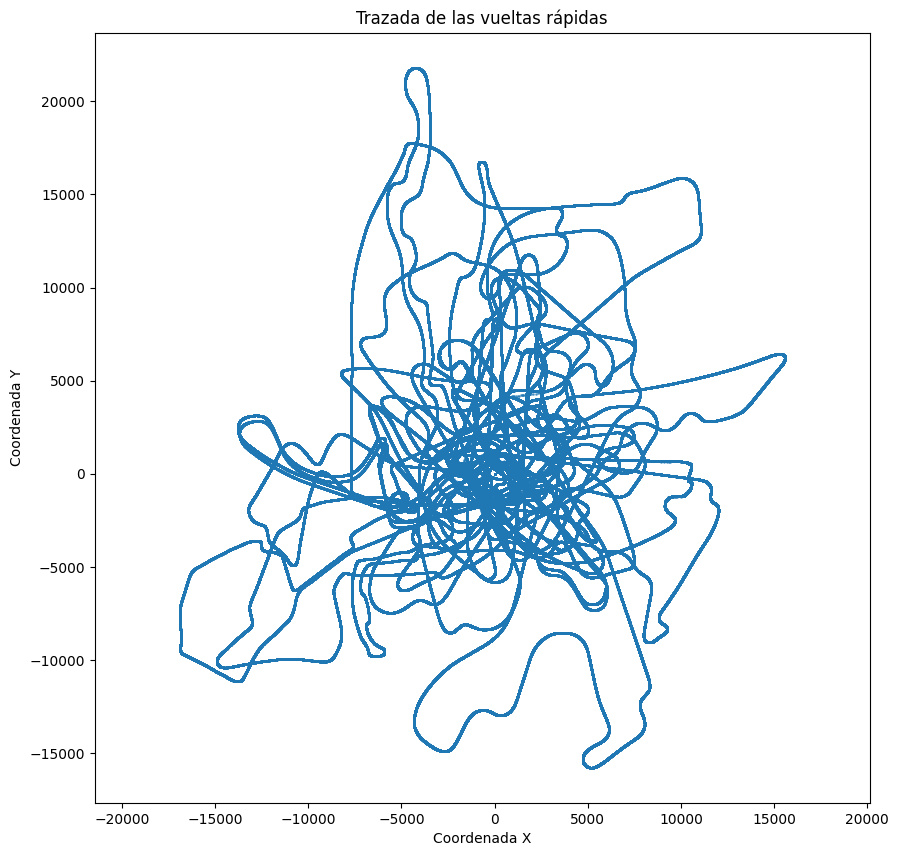

In [41]:
plt.figure(figsize=(10,10))

plt.scatter(
    location_data["x"],
    location_data["y"],
    s=1,
    alpha=0.6
)

plt.title("Trazada de las vueltas rápidas")

plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")

plt.axis("equal")

plt.show()

### Interpretación

La representación muestra la totalidad de las coordenadas registradas en el dataset de localización. Sin embargo, podemos ver que incluir simultáneamente vueltas rápidas procedentes de múltiples circuitos y temporadas, las trazadas aparecen superpuestas en un mismo plano de coordenadas. Como resultado, no es posible identificar un circuito concreto, aunque sí se observa que las coordenadas han sido registradas correctamente y permiten reconstruir la trayectoria seguida por los monoplazas.

Este resultado confirma que la información de posicionamiento es válida y podrá utilizarse posteriormente para representar circuitos individuales dentro del dashboard interactivo.


## Ejemplo: Circuito de UK 2024

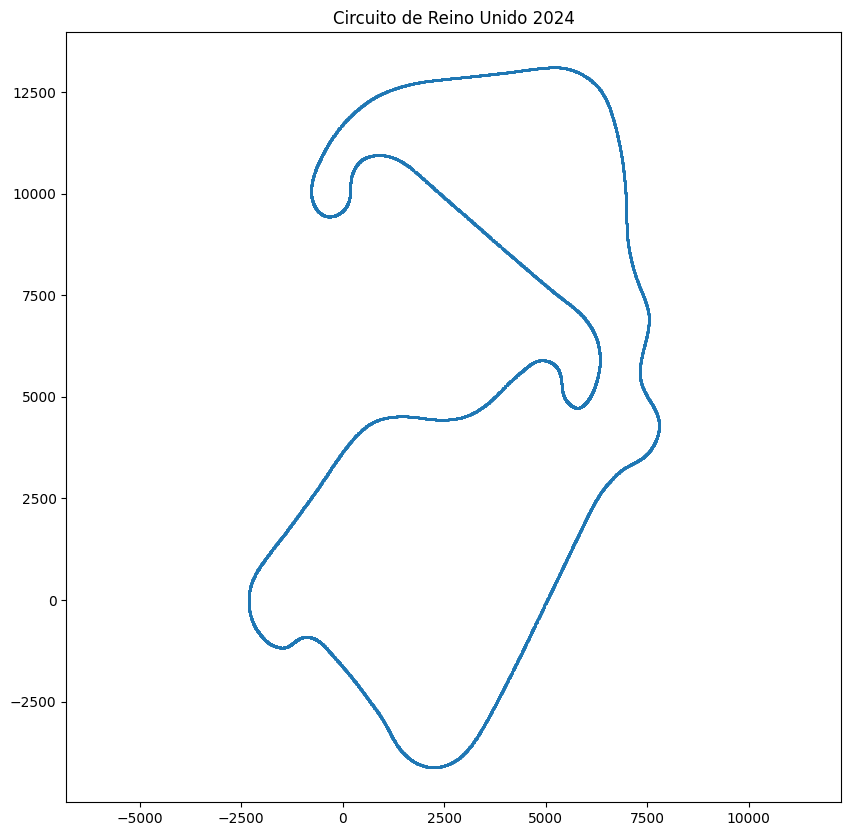

In [50]:
uk = location_data[
    (location_data["country_name"] == "United Kingdom")
    & (location_data["season"] == 2024)
]

plt.figure(figsize=(10,10))

plt.scatter(
    uk["x"],
    uk["y"],
    s=1
)

plt.title("Circuito de Reino Unido 2024")
plt.axis("equal")

plt.show()

Al aislar un único circuito desaparece la superposición vista anteriormente y puede apreciarse claramente la geometría de la pista.

La representación confirma que las coordenadas registradas permiten reconstruir con precisión el recorrido seguido por los monoplazas durante sus vueltas rápidas. Este tipo de información será especialmente útil para desarrollar visualizaciones interactivas en el dashboard final.

## Velocidad sobre la trazada

Además de reconstruir el circuito, es posible representar la velocidad registrada en cada punto de la trazada.

Para este apartado podemos unir los datos por fecha aproximada ya que ambos datasets no tienen el mismo numero de filas.

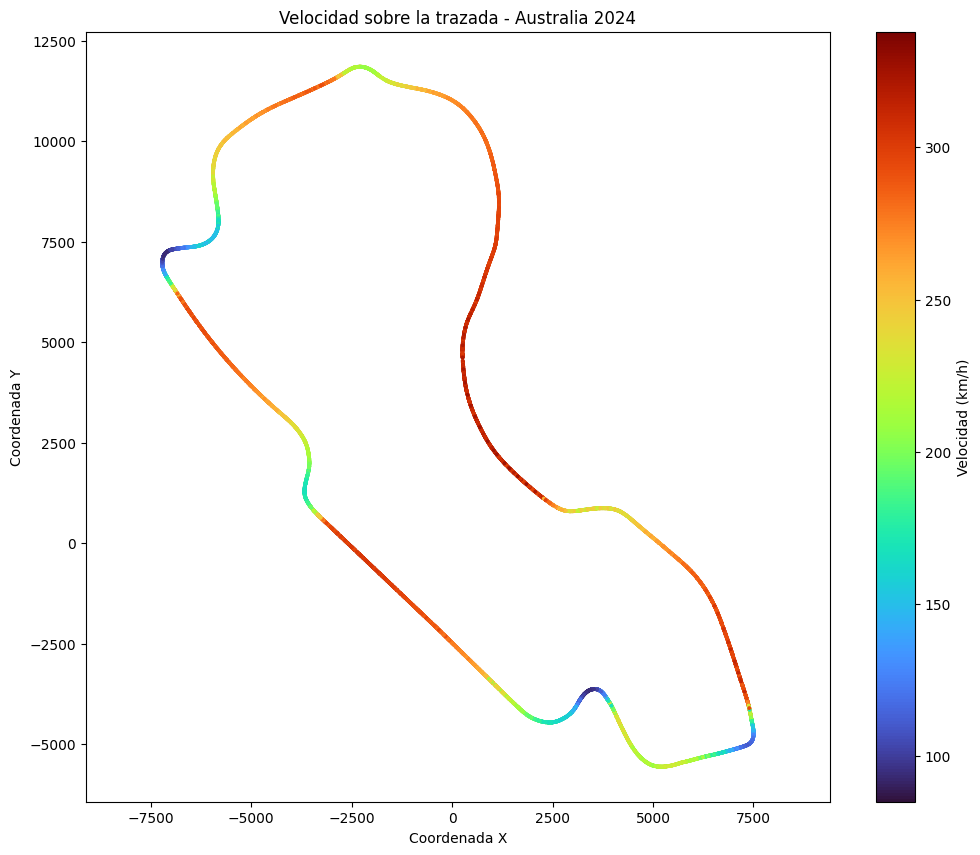

In [52]:
car_data["date"] = pd.to_datetime(
    car_data["date"],
    format="mixed",
    utc=True
)

location_data["date"] = pd.to_datetime(
    location_data["date"],
    format="mixed",
    utc=True
)

circuit_location = location_data[
    (location_data["country_name"] == "Australia") &
    (location_data["season"] == 2024)
].copy()

circuit_car = car_data[
    (car_data["country_name"] == "Australia") &
    (car_data["season"] == 2024)
].copy()

circuit_location = circuit_location.sort_values("date")
circuit_car = circuit_car.sort_values("date")

circuit_merged = pd.merge_asof(
    circuit_location,
    circuit_car[
        [
            "date",
            "session_key",
            "driver_number",
            "speed"
        ]
    ],
    on="date",
    by=[
        "session_key",
        "driver_number"
    ],
    direction="nearest"
)

plt.figure(figsize=(12,10))

scatter = plt.scatter(
    circuit_merged["x"],
    circuit_merged["y"],
    c=circuit_merged["speed"],
    s=3,
    cmap="turbo"
)

plt.colorbar(
    scatter,
    label="Velocidad (km/h)"
)

plt.title("Velocidad sobre la trazada - Australia 2024")
plt.xlabel("Coordenada X")
plt.ylabel("Coordenada Y")
plt.axis("equal")

plt.show()

### Interpretación

La representación combina la información de posicionamiento y telemetría para visualizar la velocidad registrada en cada punto de la trazada del circuito.

Los colores cálidos (amarillo, naranja y rojo) indican zonas donde los monoplazas alcanzan velocidades elevadas, normalmente asociadas a rectas o tramos de aceleración prolongada, y por el contrario, los colores fríos (verde y azul) corresponden a curvas y zonas de frenada donde la velocidad disminuye.
Este gráfico permite identificar los sectores más rápidos y más lentos del circuito, así como comprender cómo varía el rendimiento del vehículo a lo largo de una vuelta rápida.
Además, se muestra el potencial de combinar datos de localización y telemetría para desarrollar análisis avanzados y visualizaciones interactivas dentro del dashboard final del proyecto.


## Conclusiones

El análisis exploratorio realizado sobre el dataset de telemetría permite validar la calidad y consistencia de los datos obtenidos a partir de OpenF1, así como comprender el comportamiento de los monoplazas durante sus vueltas rápidas.
Las distribuciones de velocidad, RPM, uso del acelerador, frenado y selección de marchas muestran patrones coherentes con el funcionamiento real de un vehículo de Fórmula 1. Asimismo, las correlaciones observadas entre las distintas variables confirman relaciones esperadas, como la fuerte asociación entre velocidad y marcha o la relación inversa entre aceleración y frenado.
La combinación de datos de telemetría y posicionamiento ha permitido reconstruir la trazada de los circuitos y representar visualmente cómo varía la velocidad a lo largo de una vuelta. Este tipo de análisis aporta un gran valor interpretativo y demuestra el potencial de los datos disponibles para generar visualizaciones avanzadas.

En conjunto, los resultados obtenidos proporcionan una base sólida para la siguiente fase del proyecto, centrada en la limpieza final de los datos y el desarrollo de un dashboard interactivo capaz de comparar pilotos, analizar circuitos y visualizar información de rendimiento de forma intuitiva y dinámica.
